<a href="https://colab.research.google.com/github/sjensen39/CRiSSP/blob/main/CRiSSP_Sofie_Sanya.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CRiSSP: Can AI Taste with Its Eyes?
### Project for CS 171 - Intro to Machine Learning
#### Professor: Tahereh Arabghalizi
#### Project Team: Sofie J and Sanya M

## Step 1 (4/20 - 4/23): EDA

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from dask.diagnostics import ProgressBar
import dask.bag as bag
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

# Make sure to change your file path below
os.chdir('/content/drive/MyDrive/food-4/train')

#os.chdir('/content/drive/MyDrive/CRiSSPData/food-4/train')

# computing the amount of images in each class
number_classes = {'Pizza': len(os.listdir('pizza')),
  'Risotto': len(os.listdir('risotto')),
  'Steak': len(os.listdir('steak')),
  'Sushi': len(os.listdir('sushi'))}

Mounted at /content/drive


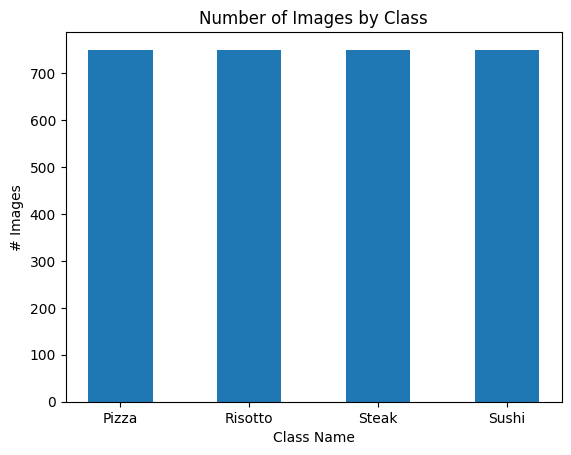

In [2]:
# plots the amount of images per class
plt.bar(number_classes.keys(), number_classes.values(), width = .5);
plt.title("Number of Images by Class");
plt.xlabel('Class Name');
plt.ylabel('# Images');

In [3]:
# dictionary of classes and their directory filepaths
directories = {'Pizza': 'pizza/',
'Risotto': 'risotto/',
'Steak': 'steak/',
'Sushi': 'sushi/'}

# returns the specified image's dimension
def get_dims(file_path):
  with Image.open(file_path) as img:
    height, width = img.size
  return height, width

# saving directory of each class
piz_dir = directories['Pizza']
ris_dir = directories['Risotto']
stk_dir = directories['Steak']
sus_dir = directories['Sushi']

# saving list of images from each class
pizza_files = os.listdir(piz_dir)
risotto_files = os.listdir(ris_dir)
steak_files = os.listdir(stk_dir)
sushi_files = os.listdir(sus_dir)

# Sample of pizza image dimensions (height, width)
# prints the first 4 image dimensions from the pizza train directory
# print('Sample of pizza image dimensions (height, width)')
# j = 0
# while(j <= 3):
#   print('Pizza Image ', (j+1), ': ', get_dims(os.path.join(piz_dir, pizza_files[j])), sep='')
#   j += 1

[########################################] | 100% Completed | 42.03 s


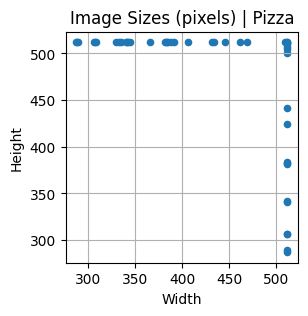

[########################################] | 100% Completed | 19.50 s


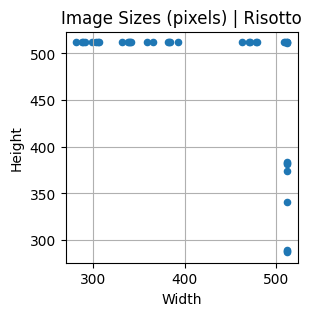

[########################################] | 100% Completed | 15.77 s


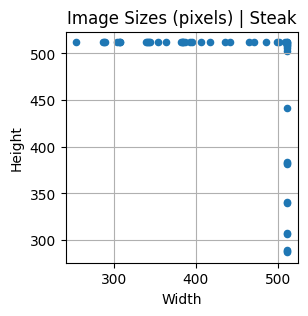

[########################################] | 100% Completed | 28.24 s


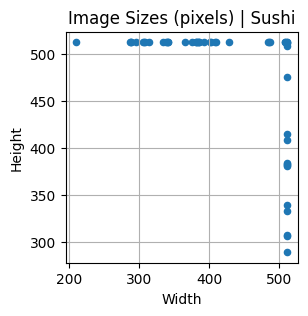

In [4]:
# computes every image dimension using Dask.bag
# collects these into a DataFrame, then finds the unique image dims
# creates a scatterplot of all the unique dims per class
for name,dir in directories.items():
  filepath = dir
  filelist = [filepath + f for f in os.listdir(filepath)]
  dims = bag.from_sequence(filelist).map(get_dims)
  with ProgressBar():
    dims = dims.compute()
    dim_df = pd.DataFrame(dims, columns=['height', 'width'])
    sizes = dim_df.groupby(['height', 'width']).size().reset_index().rename(columns={0:'count'})
  plt.figure(figsize=(3, 3)) # Create a new figure for each plot
  sizes.plot.scatter(x='width', y='height', ax=plt.gca()); # Pass current axes to plot
  plt.title('Image Sizes (pixels) | {}'.format(name))
  plt.xlabel('Width')
  plt.ylabel('Height')
  plt.grid(True)
  plt.show() # Display the plot for the current class

In [5]:
# Print the count of unique image dimensions for each class in a concise format
# print('Total count of unique image dimensions by class:')
# for name,dir in directories.items():
#   filepath = dir
#   filelist = [filepath + f for f in os.listdir(filepath)]
#   dims = bag.from_sequence(filelist).map(get_dims)
#   with ProgressBar():
#     dims = dims.compute()
#     dim_df = pd.DataFrame(dims, columns=['height', 'width'])
#     sizes = dim_df.groupby(['height', 'width']).size().reset_index().rename(columns={0:'count'})

#   print(f'\n--- {name} ({len(sizes)} unique dimensions) ---')
#   # Sort by height then width for an ordered list
#   sizes_sorted = sizes.sort_values(by=['height', 'width'])
#   for _, row in sizes_sorted.iterrows():
#     print(f"  {int(row['height'])} x {int(row['width'])}: {int(row['count'])}")

In [6]:
# Show images displayed in a 4x4 grid
# nrows = 4
# ncols = 4
# # Index for iterating over images
# pic_index = 0

# # first 8 file names of each class directory
# # computes the full path name of each sample image
# #pizza
# next_blight_pix_P = [os.path.join(piz_dir, fname)
#                   for fname in pizza_files[pic_index:pic_index+8]]

# #risotto
# next_blight_pix_R = [os.path.join(ris_dir, fname)
#                   for fname in risotto_files[pic_index:pic_index+8]]

# #steak
# next_blight_pix_St = [os.path.join(stk_dir, fname)
#                   for fname in steak_files[pic_index:pic_index+8]]

# #sushi
# next_blight_pix_Su = [os.path.join(sus_dir, fname)
#                   for fname in sushi_files[pic_index:pic_index+8]]

In [7]:
# computes the subplots for creating an 8 image sample
# for each class
# def show_image_sample(pic_directory):
#   fig = plt.gcf()
#   fig.set_size_inches(ncols * 4, nrows * 4)
#   for i, img_path in enumerate(pic_directory): # iterates through each img
#     sp = plt.subplot(nrows, ncols, i + 1)
#     sp.axis('Off')
#     img = plt.imread(img_path) # reads the image from its path
#     plt.imshow(img) # shows current subplot
#   plt.show()

# print("PIZZA")
# show_image_sample(next_blight_pix_P)
# print()
# print("RISOTTO")
# show_image_sample(next_blight_pix_R)
# print()
# print("STEAK")
# show_image_sample(next_blight_pix_St)
# print()
# print("SUSHI")
# show_image_sample(next_blight_pix_Su)

## Step 2 (4/24 - 4/27): Create and train our custom CNN

In [33]:
# when rerunning section, make sure to rerun all 4 cells in order
# so that the random seed allows for reproducibility
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import random

seed = 42

# Set seeds for reproducibility across all relevant libraries
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

# If using CUDA (GPU), set CUDA-specific seeds and determinism options
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Defines our custom CNN architecture
class CustomCNN(nn.Module):
    def __init__(self, num_classes):
        super(CustomCNN, self).__init__()
        # Convolutional Layer 1
        # Input: (batch_size, 3, H, W) - e.g., (3, 64, 64)
        # Output: (batch_size, 32, H, W)
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        # Max-Pooling Layer 1
        # Output: (batch_size, 32, H/2, W/2)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Convolutional Layer 2
        # Input: (batch_size, 32, H/2, W/2)
        # Output: (batch_size, 64, H/2, W/2)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        # Max-Pooling Layer 2
        # Output: (batch_size, 64, H/4, W/4)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fully Connected Layers
        # The input features for the first fully connected layer depend on the image size after pooling
        # Assuming input images are resized to 64x64 for this custom CNN, after two 2x2 max-pooling layers:
        # Original: 64x64 -> Pool1: 32x32 -> Pool2: 16x16
        # Flattened features: 64 channels * 16 * 16 = 16384
        self.fc1 = nn.Linear(64 * 16 * 16, 128)
        self.fc2 = nn.Linear(128, num_classes)

        # Softmax layer will be applied in the forward pass using F.softmax

    def forward(self, x):
        # -> conv1 -> ReLU -> pool1
        x = self.pool1(F.relu(self.conv1(x)))
        # -> conv2 -> ReLU -> pool2
        x = self.pool2(F.relu(self.conv2(x)))

        # Flatten the output for the fully connected layers
        # The .view() method reshapes the tensor. -1 infers the batch size.
        x = x.view(-1, 64 * 16 * 16) # Adjust the second argument based on actual image size and layers

        # -> fc1 -> ReLU
        x = F.relu(self.fc1(x))
        # -> fc2
        x = self.fc2(x)

        # Apply softmax to get probabilities. dim=1 means softmax is applied across the class dimension.
        return F.softmax(x, dim=1)

# Instantiate the model. Assuming 4 classes for Pizza, Risotto, Steak, Sushi.
# In a real scenario, you would get num_classes from your dataset, e.g., len(train_dataset.classes).
num_classes_custom_cnn = 4 # Based on the earlier EDA, there are 4 food classes
custom_cnn_model = CustomCNN(num_classes_custom_cnn)

# Print the model architecture
print(custom_cnn_model)

# Determine device and move model to it
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

custom_cnn_model = custom_cnn_model.to(device)
print(f"Model moved to {device}")

# Note: The input feature calculation (64 * 16 * 16) assumes input images are resized to 64x64 pixels.
# If your images are resized to a different dimension (e.g., 224x224), you will need to adjust this value
# accordingly in both the `__init__` and `forward` methods to match the actual output of the last pooling layer.

CustomCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=16384, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=4, bias=True)
)
Model moved to cuda


In [34]:
# Define transformations for the CustomCNN (resize to 64x64, convert to tensor, normalize)
custom_cnn_transform = transforms.Compose([
    transforms.Resize((64, 64)), # Resize images to 64x64 as expected by CustomCNN
    transforms.ToTensor(),       # Convert images to PyTorch tensors
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normalize with ImageNet stats
])

# Create datasets using ImageFolder and the custom transformations
# Ensure os.chdir was run earlier to set the correct working directory to '../train'
# If the 'train' folder is directly inside the current working directory, then just 'train' is enough
try:
    train_dataset_cnn = datasets.ImageFolder('./', transform=custom_cnn_transform)
except RuntimeError as e:
    print(f"Error loading dataset: {e}")
    print("Please ensure the current working directory is set correctly or provide the full path to your 'train' folder.")
    print("Current working directory:", os.getcwd())
    # Attempt to load from a common path if the current one fails
    train_dataset_cnn = datasets.ImageFolder('/content/drive/MyDrive/food-4/train', transform=custom_cnn_transform)
    print("Attempted to load from /content/drive/MyDrive/food-4/train")

# Create data loaders for batching
train_loader_cnn = DataLoader(train_dataset_cnn, batch_size=32, shuffle=True)

print(f"Number of training samples for CustomCNN: {len(train_dataset_cnn)}")
print(f"Number of batches per epoch for CustomCNN: {len(train_loader_cnn)}")

Number of training samples for CustomCNN: 3000
Number of batches per epoch for CustomCNN: 94


In [35]:
# Define Loss Function and Optimizer for CustomCNN
criterion_cnn = nn.CrossEntropyLoss() # Suitable for multi-class classification
optimizer_cnn = torch.optim.Adam(custom_cnn_model.parameters(), lr=0.001) # Adam optimizer with a learning rate of 0.001

In [36]:
# Training Loop for CustomCNN
num_epochs_cnn = 10 # You can adjust the number of epochs

print(f"Starting training for CustomCNN on {device}...")

for epoch in range(num_epochs_cnn):
    custom_cnn_model.train() # Set the model to training mode
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for i, (inputs, labels) in enumerate(train_loader_cnn):
        inputs, labels = inputs.to(device), labels.to(device)

        # Zero the parameter gradients
        optimizer_cnn.zero_grad()

        # Forward pass
        outputs = custom_cnn_model(inputs)
        loss = criterion_cnn(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer_cnn.step()

        # Accumulate batch loss
        running_loss += loss.item() * inputs.size(0)

        # Calculate accuracy
        _, predicted = torch.max(outputs.data, 1)
        total_samples += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

    epoch_loss = running_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples

    print(f"Epoch {epoch+1}/{num_epochs_cnn}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.4f}")

print("Training of CustomCNN complete!")
# when rerunning this cell, make sure to rerun the three before this one
# (aka the entire "Step 2" section)

Starting training for CustomCNN on cuda...
Epoch 1/10, Loss: 1.2578, Accuracy: 0.4573
Epoch 2/10, Loss: 1.1633, Accuracy: 0.5693
Epoch 3/10, Loss: 1.1053, Accuracy: 0.6327
Epoch 4/10, Loss: 1.0930, Accuracy: 0.6407
Epoch 5/10, Loss: 1.0538, Accuracy: 0.6857
Epoch 6/10, Loss: 1.0403, Accuracy: 0.7000
Epoch 7/10, Loss: 1.0089, Accuracy: 0.7320
Epoch 8/10, Loss: 0.9709, Accuracy: 0.7743
Epoch 9/10, Loss: 0.9406, Accuracy: 0.8043
Epoch 10/10, Loss: 0.9158, Accuracy: 0.8317
Training of CustomCNN complete!


## Step 3 (4/28 - 5/3): Use ResNet50 on our dataset

In [37]:
import torchvision.models as models

In [38]:
resnet_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [39]:
train_dataset_resnet = datasets.ImageFolder('/content/drive/MyDrive/food-4/train', transform=resnet_transform)
train_loader_resnet = DataLoader(train_dataset_resnet, batch_size=32, shuffle=True)

In [40]:
resnet_model = models.resnet50(pretrained=True)

In [41]:
for param in resnet_model.parameters():
    param.requires_grad = False

In [42]:
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, 4)
resnet_model = resnet_model.to(device)

In [43]:
from torch.optim import lr_scheduler

num_epochs = 6

criterion_resnet = nn.CrossEntropyLoss()

# Define the optimizer for ResNet50
optimizer_resnet = torch.optim.Adam(resnet_model.fc.parameters(), lr=0.001)

# Define a learning rate scheduler
# This scheduler will decrease the learning rate by a factor of 0.1 every 5 epochs
scheduler = lr_scheduler.StepLR(optimizer_resnet, step_size=5, gamma=0.1)

print(f"Starting training for ResNet50 on {device}...")

for epoch in range(num_epochs):
    resnet_model.train() # Set the model to training mode
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for images, labels in train_loader_resnet:
        images, labels = images.to(device), labels.to(device)

        optimizer_resnet.zero_grad()
        outputs = resnet_model(images)
        loss = criterion_resnet(outputs, labels)
        loss.backward()
        optimizer_resnet.step()

        running_loss += loss.item() * images.size(0)

        # Calculate training accuracy
        _, predicted = torch.max(outputs.data, 1)
        total_samples += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

    # Step the scheduler after each epoch
    scheduler.step()

    epoch_loss = running_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_loss:.4f}, Train Accuracy: {epoch_accuracy:.4f}")

print("Training of ResNet50 complete!")

Starting training for ResNet50 on cuda...
Epoch [1/6], Train Loss: 0.6817, Train Accuracy: 0.7713
Epoch [2/6], Train Loss: 0.3775, Train Accuracy: 0.8813
Epoch [3/6], Train Loss: 0.3222, Train Accuracy: 0.8940
Epoch [4/6], Train Loss: 0.2946, Train Accuracy: 0.9060
Epoch [5/6], Train Loss: 0.2741, Train Accuracy: 0.9050
Epoch [6/6], Train Loss: 0.2422, Train Accuracy: 0.9183
Training of ResNet50 complete!


## Step 4 (5/4 - 5/7): Model evaluation


In [44]:
import torchvision.transforms as transforms
from torchvision import datasets # Explicitly import datasets here

# Define transformations for the CustomCNN test set (resize to 64x64, convert to tensor, normalize)
custom_cnn_test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create test dataset and DataLoader for CustomCNN
# Assuming test data is located in /content/drive/MyDrive/food-4/test
try:
    test_dataset_cnn = datasets.ImageFolder('/content/drive/MyDrive/food-4/test', transform=custom_cnn_test_transform)
    test_loader_cnn = DataLoader(test_dataset_cnn, batch_size=32, shuffle=False) # Shuffle False for evaluation
    print(f"Number of test samples for CustomCNN: {len(test_dataset_cnn)}")
    print(f"Number of batches per epoch for CustomCNN test: {len(test_loader_cnn)}")
except Exception as e:
    print(f"Error loading CustomCNN test dataset: {e}")
    test_dataset_cnn = None
    test_loader_cnn = None

Number of test samples for CustomCNN: 1000
Number of batches per epoch for CustomCNN test: 32


In [45]:
import torchvision.transforms as transforms
from torchvision import datasets # Explicitly import datasets here

# Define transformations for the ResNet50 test set (resize to 224x224, convert to tensor, normalize)
resnet_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Create test dataset and DataLoader for ResNet50
# Assuming test data is located in /content/drive/MyDrive/food-4/test
try:
    test_dataset_resnet = datasets.ImageFolder('/content/drive/MyDrive/food-4/test', transform=resnet_test_transform)
    test_loader_resnet = DataLoader(test_dataset_resnet, batch_size=32, shuffle=False) # Shuffle False for evaluation
    print(f"Number of test samples for ResNet50: {len(test_dataset_resnet)}")
    print(f"Number of batches per epoch for ResNet50 test: {len(test_loader_resnet)}")
except Exception as e:
    print(f"Error loading ResNet50 test dataset: {e}")
    test_dataset_resnet = None
    test_loader_resnet = None

Number of test samples for ResNet50: 1000
Number of batches per epoch for ResNet50 test: 32


In [46]:
# Evaluation function
def evaluate_model(model, dataloader, device):
    model.eval() # Set model to evaluation mode
    correct = 0
    total = 0
    with torch.no_grad(): # Disable gradient calculation during inference
        if dataloader is None:
            print("Dataloader is None, cannot evaluate.")
            return 0.0
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100 * correct / total
    return accuracy

print("Evaluation function defined.")

Evaluation function defined.


In [47]:
# Evaluate CustomCNN
if test_loader_cnn:
    custom_cnn_accuracy = evaluate_model(custom_cnn_model, test_loader_cnn, device)
    print(f'CustomCNN Test Accuracy: {custom_cnn_accuracy:.2f}%')
else:
    print('CustomCNN test loader not available, skipping evaluation.')

CustomCNN Test Accuracy: 60.40%


In [48]:
# Evaluate ResNet50
if test_loader_resnet:
    resnet_accuracy = evaluate_model(resnet_model, test_loader_resnet, device)
    print(f'ResNet50 Test Accuracy: {resnet_accuracy:.2f}%')
else:
    print('ResNet50 test loader not available, skipping evaluation.')

ResNet50 Test Accuracy: 89.20%


## Step 5 (5/5 - 5/8): Model comparison

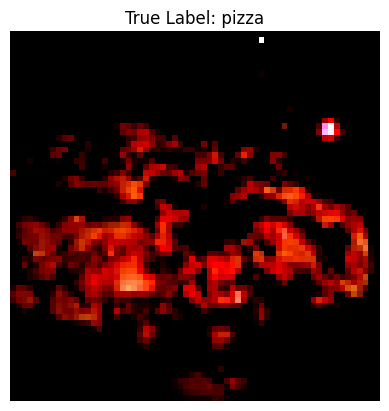

Selected image at index 150 has true label: pizza


In [62]:
import matplotlib.pyplot as plt

# Choose an image from the test set (e.g., the 50th image)
# You can change this index to experiment with different images
image_index = 150

# Get the image and its true label from the CustomCNN test dataset
# (Both test_dataset_cnn and test_dataset_resnet use the same ImageFolder structure)
original_image, true_label_idx = test_dataset_cnn[image_index]

# Get the class names
class_names = test_dataset_cnn.classes
true_label_name = class_names[true_label_idx]

# Display the original image and its true label
plt.imshow(original_image.permute(1, 2, 0)) # Permute to (H, W, C) for matplotlib
plt.title(f"True Label: {true_label_name}")
plt.axis('off')
plt.show()

print(f"Selected image at index {image_index} has true label: {true_label_name}")

In [63]:
# Preprocess and predict with CustomCNN

# Re-obtain the image to apply transformations directly on the PIL Image (not the tensor)
# This is necessary because test_dataset_cnn[index] returns the transformed tensor
# We need the raw image to apply specific transformations again for prediction
raw_image, _ = datasets.ImageFolder('/content/drive/MyDrive/food-4/test')[image_index]

# Apply CustomCNN specific transformations
custom_cnn_input = custom_cnn_test_transform(raw_image).unsqueeze(0).to(device) # Add batch dimension and move to device

# Make prediction with CustomCNN
custom_cnn_model.eval() # Set model to evaluation mode
with torch.no_grad():
    custom_cnn_output = custom_cnn_model(custom_cnn_input)
    custom_cnn_probabilities = torch.nn.functional.softmax(custom_cnn_output, dim=1)
    _, custom_cnn_predicted_idx = torch.max(custom_cnn_probabilities, 1)

custom_cnn_predicted_class = class_names[custom_cnn_predicted_idx.item()]
custom_cnn_confidence = custom_cnn_probabilities[0, custom_cnn_predicted_idx.item()].item()

print(f"CustomCNN Prediction: {custom_cnn_predicted_class} (Confidence: {custom_cnn_confidence:.2f})")

CustomCNN Prediction: pizza (Confidence: 0.46)


In [64]:
# Preprocess and predict with ResNet50

# The raw_image is already loaded in the previous cell

# Apply ResNet50 specific transformations
resnet_input = resnet_test_transform(raw_image).unsqueeze(0).to(device) # Add batch dimension and move to device

# Make prediction with ResNet50
resnet_model.eval() # Set model to evaluation mode
with torch.no_grad():
    resnet_output = resnet_model(resnet_input)
    resnet_probabilities = torch.nn.functional.softmax(resnet_output, dim=1)
    _, resnet_predicted_idx = torch.max(resnet_probabilities, 1)

# Safely get the predicted index, ensuring it's within bounds
predicted_idx_item = resnet_predicted_idx.item()
if predicted_idx_item < 0 or predicted_idx_item >= len(class_names):
    # If the predicted index is out of range, default to class 0 or handle as unknown
    print(f"Warning: ResNet50 predicted an out-of-range index: {predicted_idx_item}. Defaulting to class 0.")
    predicted_idx_item = 0 # Or you could set it to a special 'unknown' class

resnet_predicted_class = class_names[predicted_idx_item]
resnet_confidence = resnet_probabilities[0, predicted_idx_item].item()

print(f"ResNet50 Prediction: {resnet_predicted_class} (Confidence: {resnet_confidence:.2f})")

ResNet50 Prediction: pizza (Confidence: 0.99)
